In [7]:
import pandas as pd
import matplotlib.pyplot as plt

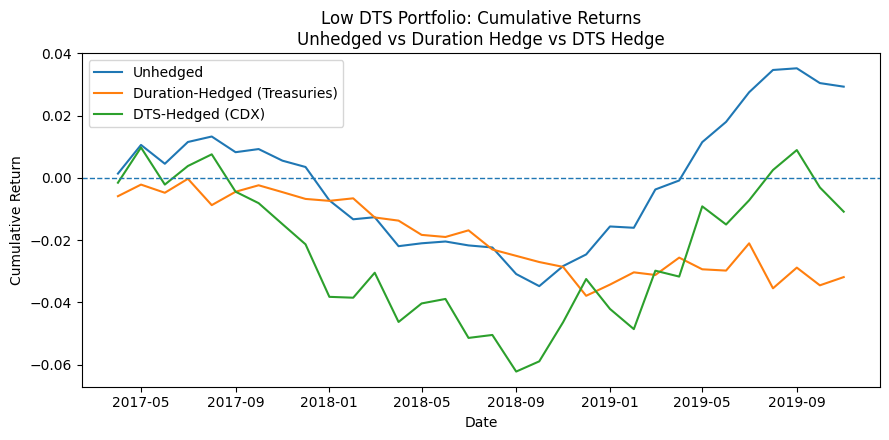

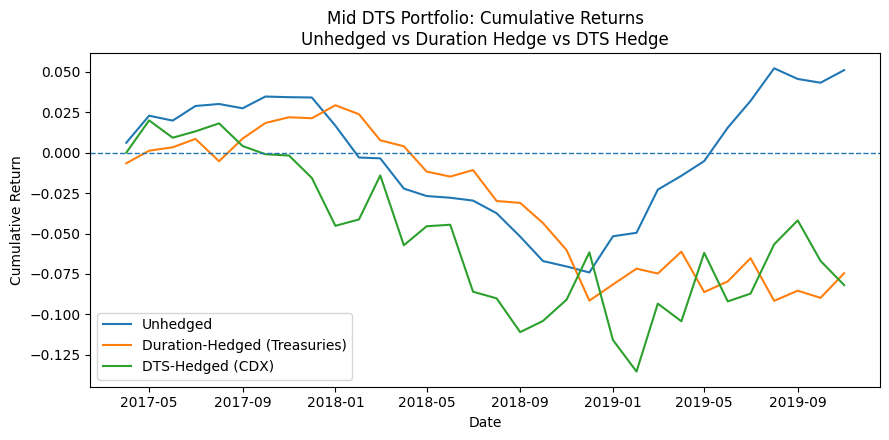

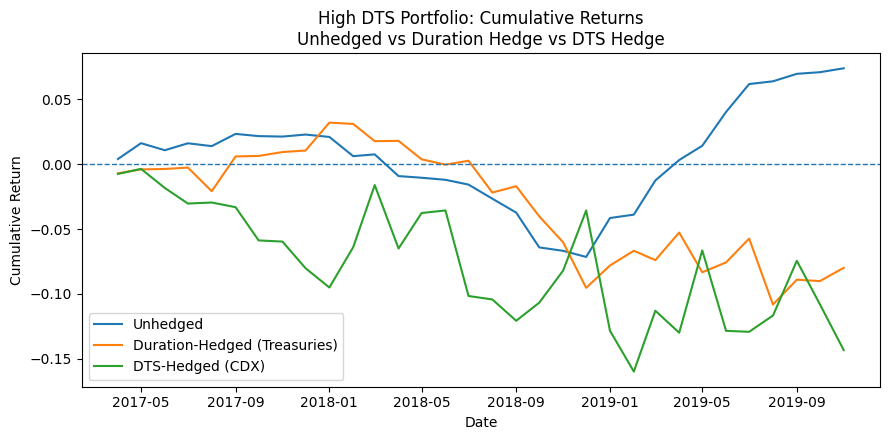

In [8]:
# =========================
# 1. LOAD PORTFOLIO CSVs
# =========================

low_opt_dur  = pd.read_csv('./portfolios/dur_hedged/low_opt.csv')
mid_opt_dur  = pd.read_csv('./portfolios/dur_hedged/mid_opt.csv')
high_opt_dur = pd.read_csv('./portfolios/dur_hedged/high_opt.csv')

low_opt_dts  = pd.read_csv('./portfolios/dts_hedged/low_opt.csv')
mid_opt_dts  = pd.read_csv('./portfolios/dts_hedged/mid_opt.csv')
high_opt_dts = pd.read_csv('./portfolios/dts_hedged/high_opt.csv')


# =========================
# 2. HELPER: MAKE DATE COL
# =========================

def add_date_column(df):
    """
    Create a datetime column called 'date' from either:
    - 'ym' (string like '2019-07') interpreted as Year-Month
    - or 'month' (string or period) parsable by to_datetime
    """
    if 'ym' in df.columns:
        df['date'] = pd.PeriodIndex(df['ym'], freq='M').to_timestamp()
    elif 'month' in df.columns:
        df['date'] = pd.to_datetime(df['month'].astype(str))
    else:
        raise ValueError("DataFrame must have a 'ym' or 'month' column.")

    return df


low_opt_dur  = add_date_column(low_opt_dur)
mid_opt_dur  = add_date_column(mid_opt_dur)
high_opt_dur = add_date_column(high_opt_dur)

low_opt_dts  = add_date_column(low_opt_dts)
mid_opt_dts  = add_date_column(mid_opt_dts)
high_opt_dts = add_date_column(high_opt_dts)


# =========================
# 3. MERGE DUR + DTS SERIES
# =========================

def merge_dur_dts(dur_df, dts_df):
    """
    Merge duration-hedged and DTS-hedged data on 'date'.
    Assumes:
      - dur_df has 'cum_ret' (unhedged) and 'cum_hedged' (duration-hedged)
      - dts_df has 'cum_dn_hedged' (DTS-hedged)
    """
    dur_keep = dur_df[['date', 'cum_ret', 'cum_hedged']].copy()
    dts_keep = dts_df[['date', 'cum_dn_hedged']].copy()

    merged = pd.merge(dur_keep, dts_keep, on='date', how='inner')
    return merged.sort_values('date')


low_merged  = merge_dur_dts(low_opt_dur,  low_opt_dts)
mid_merged  = merge_dur_dts(mid_opt_dur,  mid_opt_dts)
high_merged = merge_dur_dts(high_opt_dur, high_opt_dts)


# =========================
# 4. PLOTTING FUNCTION
# =========================

def plot_cumulative_triple(df, title):
    """
    Plot cumulative returns for:
      - Unhedged (cum_ret)
      - Duration-hedged (cum_hedged)
      - DTS-hedged (cum_dn_hedged)
    """
    plt.figure(figsize=(9, 4.5))
    plt.plot(df['date'], df['cum_ret'],        label='Unhedged')
    plt.plot(df['date'], df['cum_hedged'],     label='Duration-Hedged (Treasuries)')
    plt.plot(df['date'], df['cum_dn_hedged'],  label='DTS-Hedged (CDX)')

    plt.axhline(0, linestyle='--', linewidth=1)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 5. MAKE THE 3 FIGURES
# =========================

plot_cumulative_triple(low_merged,
    "Low DTS Portfolio: Cumulative Returns\nUnhedged vs Duration Hedge vs DTS Hedge"
)

plot_cumulative_triple(mid_merged,
    "Mid DTS Portfolio: Cumulative Returns\nUnhedged vs Duration Hedge vs DTS Hedge"
)

plot_cumulative_triple(high_merged,
    "High DTS Portfolio: Cumulative Returns\nUnhedged vs Duration Hedge vs DTS Hedge"
)
